# Aircraft/Airline Low-Risk Potential Analysis

# Business Understanding

### Overview
The project aims to identify the lowest-risk aircraft to support the company entry into exploring expansion into the airline industry. This insight will guide the head of the new aviation division in making informed purchasing decisions.

# Data Understanding

#### Importing Key Python libraries for data analysis and visualization

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#### Loading 'AviationData.csv' file into a Pandas Dataframe 

In [24]:
df = pd.read_csv('AviationData.csv', encoding='latin-1', low_memory=False)
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [3]:
df.shape

(88889, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50249 non-null  object 
 9   Airport.Name            52790 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87572 non-null  object 
 14  Make                    88826 non-null

Retrieving the count of the number of missing values in the column of the DataFrame

In [5]:
df.isna().sum()

Event.Id                      0
Investigation.Type            0
Accident.Number               0
Event.Date                    0
Location                     52
Country                     226
Latitude                  54507
Longitude                 54516
Airport.Code              38640
Airport.Name              36099
Injury.Severity            1000
Aircraft.damage            3194
Aircraft.Category         56602
Registration.Number        1317
Make                         63
Model                        92
Amateur.Built               102
Number.of.Engines          6084
Engine.Type                7077
FAR.Description           56866
Schedule                  76307
Purpose.of.flight          6192
Air.carrier               72241
Total.Fatal.Injuries      11401
Total.Serious.Injuries    12510
Total.Minor.Injuries      11933
Total.Uninjured            5912
Weather.Condition          4492
Broad.phase.of.flight     27165
Report.Status              6381
Publication.Date          13771
dtype: i

#### Retrieving the count of the number of missing values in the column of the DataFrame as a percentage

In [6]:
df.isnull().sum()/len(df)*100

Event.Id                   0.000000
Investigation.Type         0.000000
Accident.Number            0.000000
Event.Date                 0.000000
Location                   0.058500
Country                    0.254250
Latitude                  61.320298
Longitude                 61.330423
Airport.Code              43.469946
Airport.Name              40.611324
Injury.Severity            1.124999
Aircraft.damage            3.593246
Aircraft.Category         63.677170
Registration.Number        1.481623
Make                       0.070875
Model                      0.103500
Amateur.Built              0.114750
Number.of.Engines          6.844491
Engine.Type                7.961615
FAR.Description           63.974170
Schedule                  85.845268
Purpose.of.flight          6.965991
Air.carrier               81.271023
Total.Fatal.Injuries      12.826109
Total.Serious.Injuries    14.073732
Total.Minor.Injuries      13.424608
Total.Uninjured            6.650992
Weather.Condition          5

## Data Preparation

#### Dropping unnecessary columns, a lot of these columns have a high missing (NaN) values

In [7]:
dropped_cols1 = ['Accident.Number', 
                 'Latitude', 
                 'Longitude', 
                 'Airport.Code', 
                 'Airport.Name', 
                 'Aircraft.Category', 
                 'Registration.Number', 
                 'Amateur.Built', 
                 'Engine.Type', 
                 'FAR.Description', 
                 'Schedule', 
                 'Air.carrier', 
                 'Broad.phase.of.flight', 
                 'Report.Status', 
                 'Publication.Date']

df = df.drop(columns=dropped_cols1)

In [26]:
df.head(10)

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
5,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,42.445277,-70.758333,NaN,NaN,...,NaN,Air Canada,NaN,NaN,1.0,44.0,VMC,Climb,Probable Cause,19-09-2017
6,20001218X45446,Accident,CHI81LA106,1981-08-01,"COTTON, MN",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,IMC,Unknown,Probable Cause,06-11-2001
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,NaN,NaN,BLACKBURN AG STRIP,...,Personal,NaN,0.0,0.0,0.0,2.0,VMC,Takeoff,Probable Cause,01-01-1982
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,NaN,NaN,N58,HANOVER,...,Business,NaN,0.0,0.0,0.0,2.0,IMC,Landing,Probable Cause,01-01-1982
9,20020909X01560,Accident,MIA82DA029,1982-01-01,"JACKSONVILLE, FL",United States,NaN,NaN,JAX,JACKSONVILLE INTL,...,Personal,NaN,0.0,0.0,3.0,0.0,IMC,Cruise,Probable Cause,01-01-1982


#### The DataFrame has been reduces to 16 columns now

In [9]:
df.shape

(88889, 16)

In [10]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Event.Date', 'Location', 'Country',
       'Injury.Severity', 'Aircraft.damage', 'Make', 'Model',
       'Number.of.Engines', 'Purpose.of.flight', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition'],
      dtype='object')

In [11]:
df.describe()

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,82805.000000,77488.000000,76379.000000,76956.000000,82977.000000
mean,1.146585,0.647855,0.279881,0.357061,5.325440
std,0.446510,5.485960,1.544084,2.235625,27.913634
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000
max,8.000000,349.000000,161.000000,380.000000,699.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Event.Date              88889 non-null  object 
 3   Location                88837 non-null  object 
 4   Country                 88663 non-null  object 
 5   Injury.Severity         87889 non-null  object 
 6   Aircraft.damage         85695 non-null  object 
 7   Make                    88826 non-null  object 
 8   Model                   88797 non-null  object 
 9   Number.of.Engines       82805 non-null  float64
 10  Purpose.of.flight       82697 non-null  object 
 11  Total.Fatal.Injuries    77488 non-null  float64
 12  Total.Serious.Injuries  76379 non-null  float64
 13  Total.Minor.Injuries    76956 non-null  float64
 14  Total.Uninjured         82977 non-null

In [13]:
df.isnull().sum()/len(df)*100

Event.Id                   0.000000
Investigation.Type         0.000000
Event.Date                 0.000000
Location                   0.058500
Country                    0.254250
Injury.Severity            1.124999
Aircraft.damage            3.593246
Make                       0.070875
Model                      0.103500
Number.of.Engines          6.844491
Purpose.of.flight          6.965991
Total.Fatal.Injuries      12.826109
Total.Serious.Injuries    14.073732
Total.Minor.Injuries      13.424608
Total.Uninjured            6.650992
Weather.Condition          5.053494
dtype: float64

#### Investigating to see how many times each country appears in the data set,  determined that the United States is the one that appears the most. So we will be focusing on the United States for this analysis and resetting the index

In [14]:
df['Country'].value_counts()

United States                    82248
Brazil                             374
Canada                             359
Mexico                             358
United Kingdom                     344
                                 ...  
Gibraltar                            1
Corsica                              1
Malampa                              1
St Vincent And The Grenadines        1
Ivory Coast                          1
Name: Country, Length: 219, dtype: int64

In [15]:
df = df[df["Country"] == "United States"]
df.reset_index(drop=True, inplace=True)
df.head(10) 

,Event.Id,Investigation.Type,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Make,Model,Number.of.Engines,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition
0,20001218X45444,Accident,1948-10-24,"MOOSE CREEK, ID",United States,Fatal(2),Destroyed,Stinson,108-3,1.0,Personal,2.0,0.0,0.0,0.0,UNK
1,20001218X45447,Accident,1962-07-19,"BRIDGEPORT, CA",United States,Fatal(4),Destroyed,Piper,PA24-180,1.0,Personal,4.0,0.0,0.0,0.0,UNK
2,20061025X01555,Accident,1974-08-30,"Saltville, VA",United States,Fatal(3),Destroyed,Cessna,172M,1.0,Personal,3.0,NaN,NaN,NaN,IMC
3,20001218X45448,Accident,1977-06-19,"EUREKA, CA",United States,Fatal(2),Destroyed,Rockwell,112,1.0,Personal,2.0,0.0,0.0,0.0,IMC
4,20041105X01764,Accident,1979-08-02,"Canton, OH",United States,Fatal(1),Destroyed,Cessna,501,NaN,Personal,1.0,2.0,NaN,0.0,VMC
5,20170710X52551,Accident,1979-09-17,"BOSTON, MA",United States,Non-Fatal,Substantial,Mcdonnell Douglas,DC9,2.0,NaN,NaN,NaN,1.0,44.0,VMC
6,20001218X45446,Accident,1981-08-01,"COTTON, MN",United States,Fatal(4),Destroyed,Cessna,180,1.0,Personal,4.0,0.0,0.0,0.0,IMC
7,20020909X01562,Accident,1982-01-01,"PULLMAN, WA",United States,Non-Fatal,Substantial,Cessna,140,1.0,Personal,0.0,0.0,0.0,2.0,VMC
8,20020909X01561,Accident,1982-01-01,"EAST HANOVER, NJ",United States,Non-Fatal,Substantial,Cessna,401B,2.0,Business,0.0,0.0,0.0,2.0,IMC
9,20020909X01560,Accident,1982-01-01,"JACKSONVILLE, FL",United States,Non-Fatal,Substantial,North American,NAVION L-17B,1.0,Personal,0.0,0.0,3.0,0.0,IMC


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82248 entries, 0 to 82247
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                82248 non-null  object 
 1   Investigation.Type      82248 non-null  object 
 2   Event.Date              82248 non-null  object 
 3   Location                82237 non-null  object 
 4   Country                 82248 non-null  object 
 5   Injury.Severity         82140 non-null  object 
 6   Aircraft.damage         80269 non-null  object 
 7   Make                    82227 non-null  object 
 8   Model                   82210 non-null  object 
 9   Number.of.Engines       80373 non-null  float64
 10  Purpose.of.flight       79819 non-null  object 
 11  Total.Fatal.Injuries    71594 non-null  float64
 12  Total.Serious.Injuries  70873 non-null  float64
 13  Total.Minor.Injuries    71519 non-null  float64
 14  Total.Uninjured         77243 non-null

In [17]:
df.shape

(82248, 16)

Converting the 'Event.Date' column to a DateTime format, going from object to int64 and retaining just the year

In [18]:
df.loc[:, 'Event.Date'] = pd.to_datetime(df['Event.Date'])
df.loc[:, 'Years'] = df['Event.Date'].dt.year
df['Years'].head()

0    1948
1    1962
2    1974
3    1977
4    1979
Name: Years, dtype: int64

# Exploratory Data Analysis

#### Data analysis showing number of aircraft incidents in total.

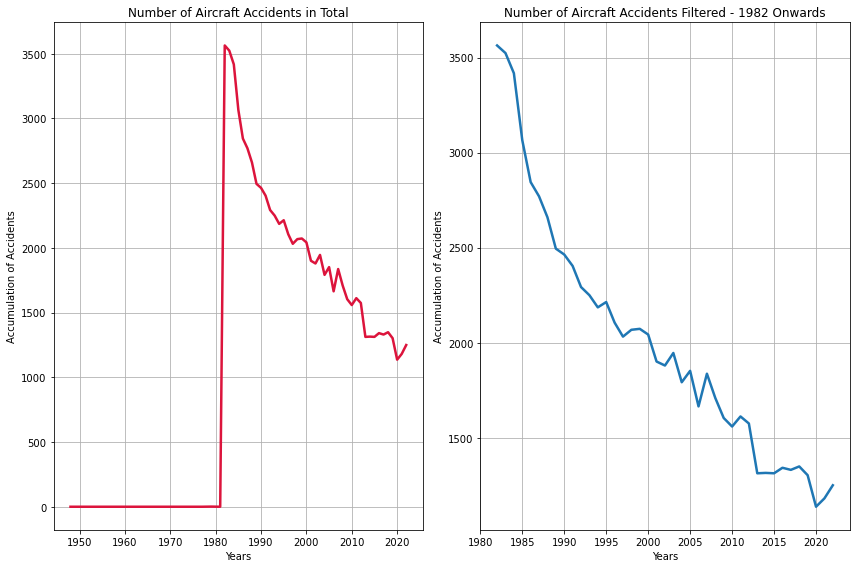

In [19]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

df_1982_filter = df[df['Years'] >= 1982] 

accident_counts_filter = df_1982_filter['Years'].value_counts().sort_index()

accident_counts_total = df['Years'].value_counts().sort_index()


ax1.plot(accident_counts_total.index,
         accident_counts_total.values,
         linestyle='-',
         linewidth=2.5,
         color='crimson')

ax1.set_title("Number of Aircraft Accidents in Total")
ax1.set_xlabel("Years")
ax1.set_ylabel("Accumulation of Accidents")

ax1.grid(True)

ax1.tick_params(axis='x', rotation=0)
               
plt.tight_layout()


ax2.plot(accident_counts_filter.index,
         accident_counts_filter.values,
         linestyle='-', 
         linewidth=2.5)

ax2.set_title("Number of Aircraft Accidents Filtered - 1982 Onwards")
ax2.set_xlabel("Years")
ax2.set_ylabel("Accumulation of Accidents")

ax2.grid(True)

ax2.tick_params(axis='x', rotation=0)
               
plt.tight_layout()
plt.show()

#### Analysis of three columns showing Fatal, Serious and Minor injuries for the years 1982 thru 2022

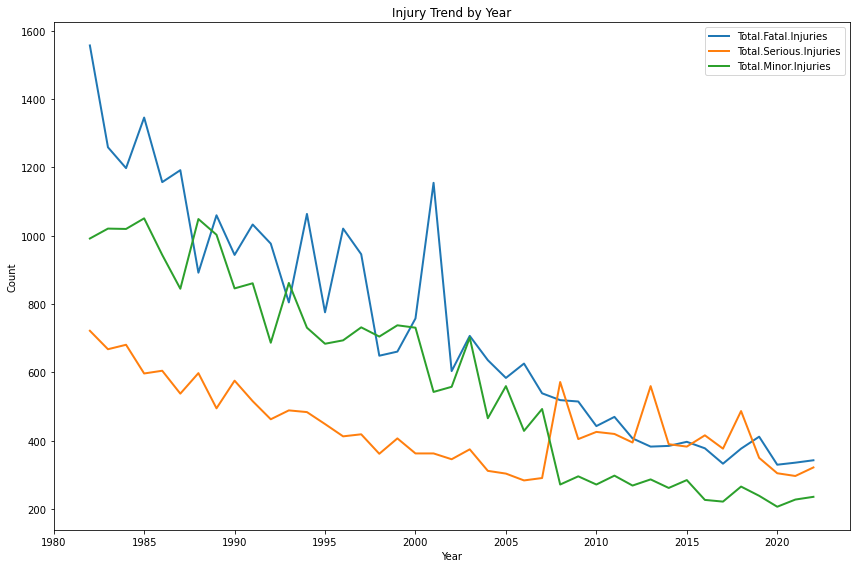

In [20]:
by_years = df[df['Years'] >= 1982].groupby('Years').sum()

fig, ax =plt.subplots(figsize=(12,8))

by_years[['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries']].plot(ax=ax, linewidth=2)

ax.legend

ax.set_title("Injury Trend by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

#### Analysis is showing the Top 10 Manufacture Accidents occurrences 

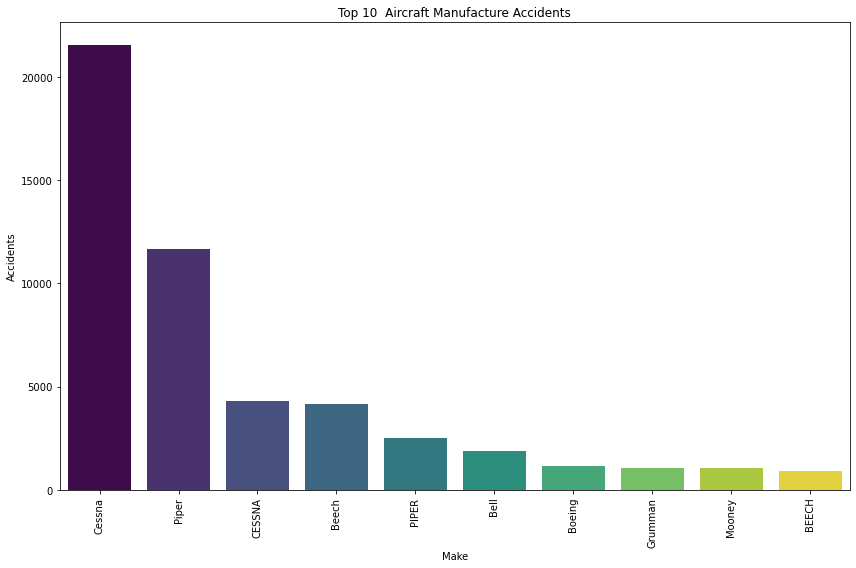

In [21]:
fig, ax = plt.subplots(figsize=(12, 8))

manf_top10_accidents = df['Make'].value_counts().nlargest(10)


manf_top10_uninjured = df['Make'].value_counts().nsmallest(10)

colors = plt.cm.viridis(np.linspace(0,1, len(manf_top10_accidents)))

sns.barplot(x=manf_top10_accidents.index, 
            y=manf_top10_accidents.values, 
            palette=colors,
            ax=ax)

ax.set_title("Top 10  Aircraft Manufacture Accidents")
ax.set_xlabel("Make")
ax.set_ylabel("Accidents")

ax.tick_params(axis='x', rotation=90)
                            
plt.tight_layout()
plt.show()

#### Analysis of Top 10 Number of Engines Accidents

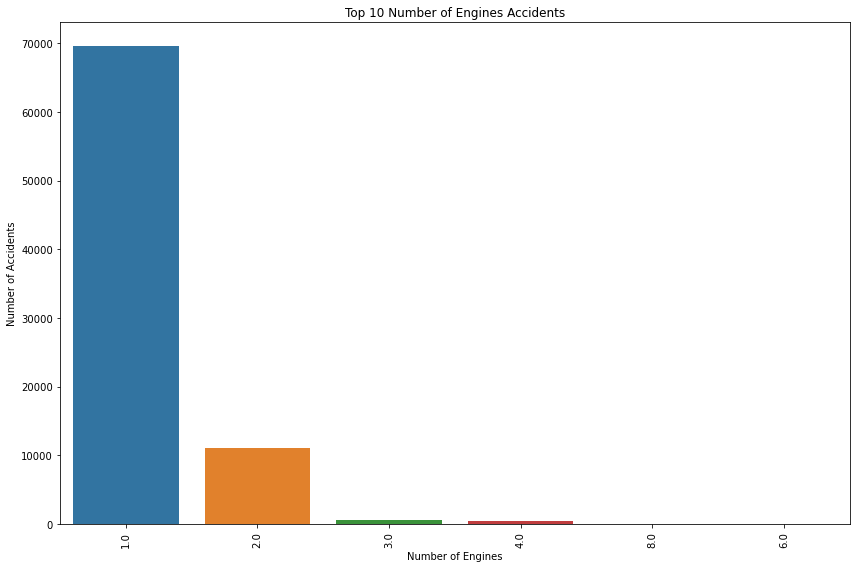

In [27]:
df['Number.of.Engines'] = df['Number.of.Engines'].replace(0.0, np.nan)

fig, ax = plt.subplots(figsize=(12, 8))

sns.countplot(data=df,
              x='Number.of.Engines',
              order=df['Number.of.Engines'].value_counts().index,
              ax=ax)

ax.set_title("Top 10 Number of Engines Accidents")
ax.set_xlabel("Number of Engines")
ax.set_ylabel("Number of Accidents")

ax.tick_params(axis='x', rotation=90)
                            
plt.tight_layout()
plt.show()

# Conclusions

Analysis is showing that the airline industry shows significant decline in incidences starting from 1985 to present a time, showing improvement in advancement in aviation technology can safety measures. Additionally, data shows that single-engine aircraft are more prone to accidents compared to two engine aircrafts. This is likely due to their mechanical limitations and operational vulnerabilities. Two engine aircraft provides good balance of power, efficiency and redundancy. This allows for a flight to continue even if one of the engines were to fail. These findings highlight the progress in aviation safety and any ongoing risks associated with smaller aircraft.

## Limitations

A clear limitation of this dataset is that the United States is the only country well-represented, while other countries have very few entries. Therefore, any conclusions drawn should primarily focus on aviation trends in the United States.

## Recommendations

To improve insight and decision-making, expanding data collection to include more countries is recommended for a more complete view of global aviation safety

## Next Steps

Next steps would include collecting more global data, improving accuracy, and analyzing trends to improve aviation safety. Collaboration with industry stakeholders and regulatory agencies can also reporting standards.